# Traffic Signal Classification

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available()
                       else 'mps' if torch.backends.mps.is_available()
                       else 'cpu')
print('using device:', device)

using device: mps


In [3]:
DATA = 'traffic_signal_dataset'

train_df = pd.read_csv(os.path.join(DATA, 'Train.csv'))
test_df = pd.read_csv(os.path.join(DATA, 'Test.csv'))
N_CLASS = train_df['ClassId'].nunique()

print('train images:', len(train_df))
print('test images:', len(test_df))
print('classes:', N_CLASS)
train_df.head(3)

train images: 39209
test images: 12630
classes: 43


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png


## Class names

In [4]:
names = ['Speed limit (20km/h)', 'Speed limit (30km/h)', 'Speed limit (50km/h)',
 'Speed limit (60km/h)', 'Speed limit (70km/h)', 'Speed limit (80km/h)',
 'End of speed limit (80km/h)', 'Speed limit (100km/h)', 'Speed limit (120km/h)',
 'No passing', 'No passing for vehicles over 3.5t', 'Right of way at next intersection',
 'Priority road', 'Yield', 'Stop', 'No vehicles', 'Vehicles over 3.5t prohibited',
 'No entry', 'General caution', 'Dangerous curve left', 'Dangerous curve right',
 'Double curve', 'Bumpy road', 'Slippery road', 'Road narrows on the right',
 'Road work', 'Traffic signals', 'Pedestrians', 'Children crossing',
 'Bicycles crossing', 'Beware of ice or snow', 'Wild animals crossing',
 'End of all speed and passing limits', 'Turn right ahead', 'Turn left ahead',
 'Ahead only', 'Go straight or right', 'Go straight or left', 'Keep right',
 'Keep left', 'Roundabout mandatory', 'End of no passing',
 'End of no passing for vehicles over 3.5t']
len(names)

43

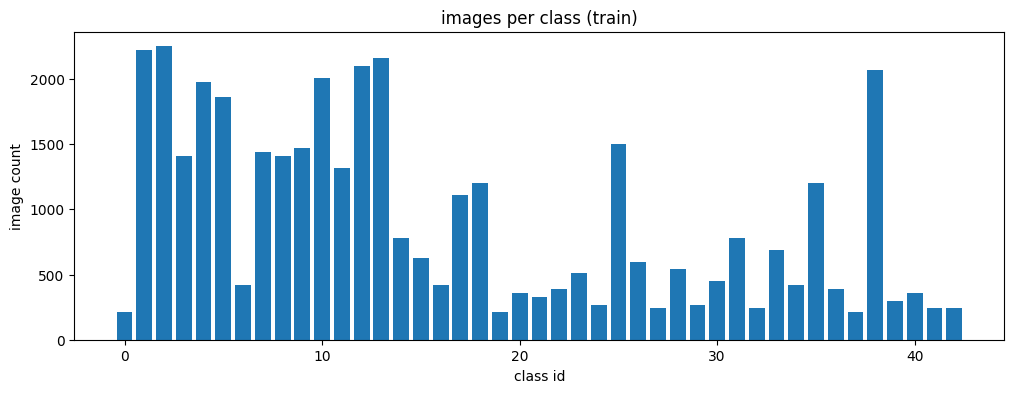

min 210 max 2250 ratio 10.7


In [5]:
counts = train_df['ClassId'].value_counts().sort_index()
plt.figure(figsize=(12, 4))
plt.bar(counts.index, counts.values)
plt.xlabel('class id'); plt.ylabel('image count')
plt.title('images per class (train)')
plt.show()
print('min', counts.min(), 'max', counts.max(), 'ratio', round(counts.max() / counts.min(), 1))

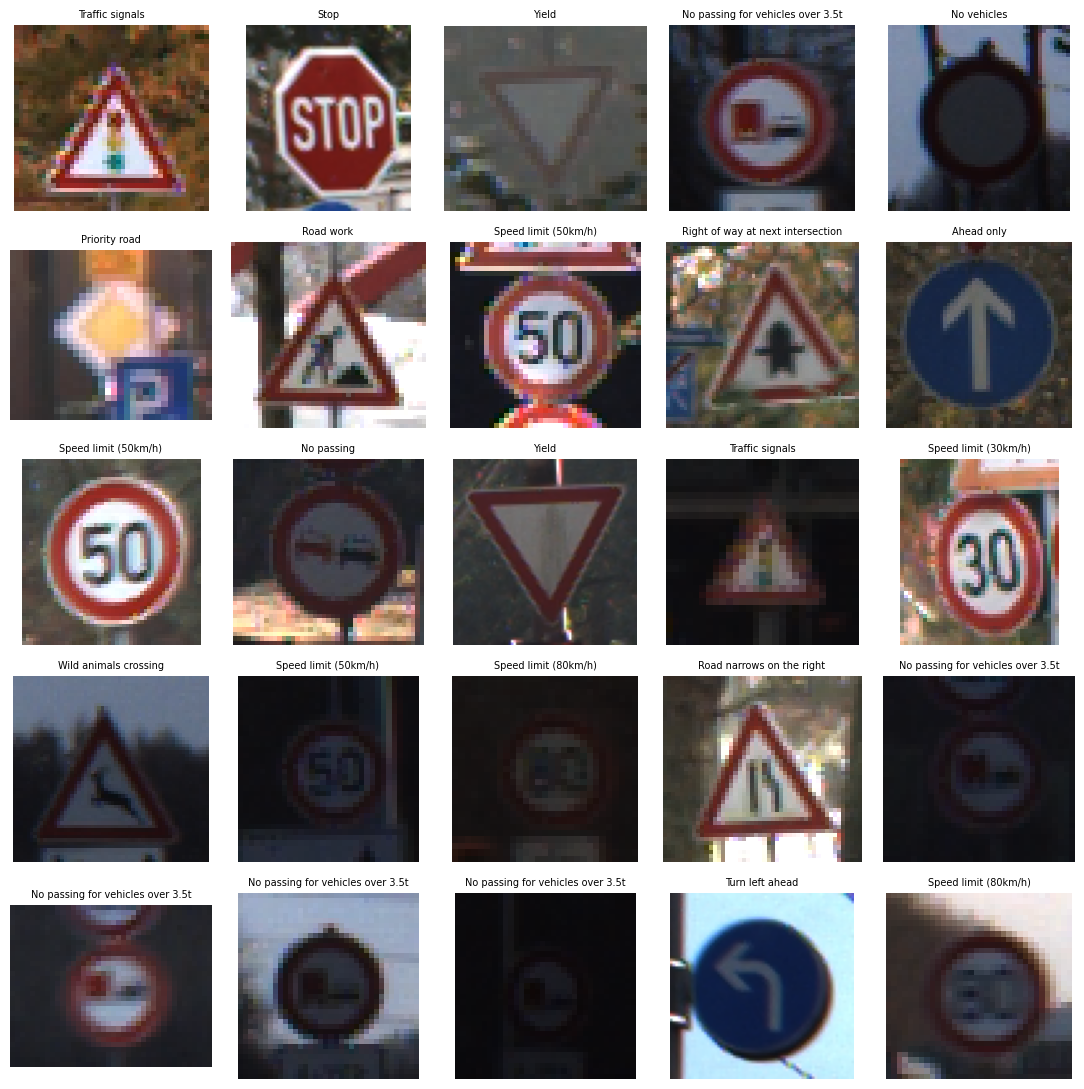

In [6]:
samp = train_df.sample(25, random_state=seed).reset_index(drop=True)
fig, ax = plt.subplots(5, 5, figsize=(11, 11))
for a, (_, r) in zip(ax.flat, samp.iterrows()):
    img = Image.open(os.path.join(DATA, r['Path'])).convert('RGB')
    a.imshow(img); a.axis('off')
    a.set_title(names[r['ClassId']], fontsize=7)
plt.tight_layout(); plt.show()

## Class imbalance

In [7]:
freq = train_df['ClassId'].value_counts().sort_index().values
class_w = torch.tensor(len(train_df) / (N_CLASS * freq), dtype=torch.float32).to(device)

In [8]:
IMG = 64 if device.type != 'cpu' else 48

RES_IMG = 224 if device.type != 'cpu' else 96

imnet = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

aug = [transforms.RandomRotation(15),
       transforms.ColorJitter(0.3, 0.3, 0.3),
       transforms.RandomPerspective(0.2, p=0.5)]

tf_train_cnn = transforms.Compose([transforms.Resize((IMG, IMG))] + aug + [transforms.ToTensor()])
tf_eval_cnn = transforms.Compose([transforms.Resize((IMG, IMG)), transforms.ToTensor()])
tf_train_res = transforms.Compose([transforms.Resize((RES_IMG, RES_IMG))] + aug + [transforms.ToTensor(), imnet])
tf_eval_res = transforms.Compose([transforms.Resize((RES_IMG, RES_IMG)), transforms.ToTensor(), imnet])

In [9]:
class GTSRB(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True)
        self.tf = tf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(os.path.join(DATA, r['Path'])).convert('RGB')
        return self.tf(img), int(r['ClassId'])

# 80/20 train val split
tr_df = train_df.sample(frac=0.8, random_state=seed)
va_df = train_df.drop(tr_df.index)
print('train', len(tr_df), 'val', len(va_df), 'test', len(test_df))

BS = 128
cnn_tr = DataLoader(GTSRB(tr_df, tf_train_cnn), batch_size=BS, shuffle=True)
cnn_va = DataLoader(GTSRB(va_df, tf_eval_cnn), batch_size=BS, shuffle=False)
cnn_te = DataLoader(GTSRB(test_df, tf_eval_cnn), batch_size=BS, shuffle=False)

train 31367 val 7842 test 12630


## Model 1: cnn from scratch

In [10]:
class CNN(nn.Module):
    def __init__(self, n=N_CLASS):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)))
        self.head = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, n))

    def forward(self, x):
        return self.head(self.feat(x))

In [11]:
lr = 1e-3
epochs = 10 if device.type != 'cpu' else 5

def fit(model, tr, va, epochs, lr, save_path):
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_w)
    hist = {'tr_loss': [], 'va_loss': [], 'va_acc': []}
    best = 0.0
    for ep in range(epochs):
        model.train()
        tl = 0.0
        for x, y in tr:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
            tl += loss.item() * x.size(0)
        model.eval()
        vl = 0.0; correct = 0; n = 0
        with torch.no_grad():
            for x, y in va:
                x, y = x.to(device), y.to(device)
                out = model(x)
                vl += crit(out, y).item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                n += x.size(0)
        h = (tl / len(tr.dataset), vl / n, correct / n)
        for k, v in zip(hist, h):
            hist[k].append(v)
        if h[2] > best:
            best = h[2]
            torch.save(model.state_dict(), save_path)
        print(f'epoch {ep+1}/{epochs}  tr_loss {h[0]:.3f}  va_loss {h[1]:.3f}  va_acc {h[2]:.3f}')
    print('best val acc', round(best, 4))
    return hist

def predict(model, loader):
    model.eval()
    ps, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            ps.append(model(x.to(device)).argmax(1).cpu())
            ys.append(y)
    return torch.cat(ps).numpy(), torch.cat(ys).numpy()

cnn = CNN().to(device)
cnn_hist = fit(cnn, cnn_tr, cnn_va, epochs, lr, 'best_cnn.pt')

epoch 1/10  tr_loss 1.651  va_loss 0.545  va_acc 0.812


epoch 2/10  tr_loss 0.301  va_loss 0.223  va_acc 0.914


epoch 3/10  tr_loss 0.157  va_loss 0.078  va_acc 0.976


epoch 4/10  tr_loss 0.100  va_loss 0.052  va_acc 0.986


epoch 5/10  tr_loss 0.088  va_loss 0.029  va_acc 0.990


epoch 6/10  tr_loss 0.057  va_loss 0.022  va_acc 0.994


epoch 7/10  tr_loss 0.061  va_loss 0.031  va_acc 0.990


epoch 8/10  tr_loss 0.058  va_loss 0.034  va_acc 0.990


epoch 9/10  tr_loss 0.043  va_loss 0.016  va_acc 0.995


epoch 10/10  tr_loss 0.050  va_loss 0.018  va_acc 0.995
best val acc 0.9952


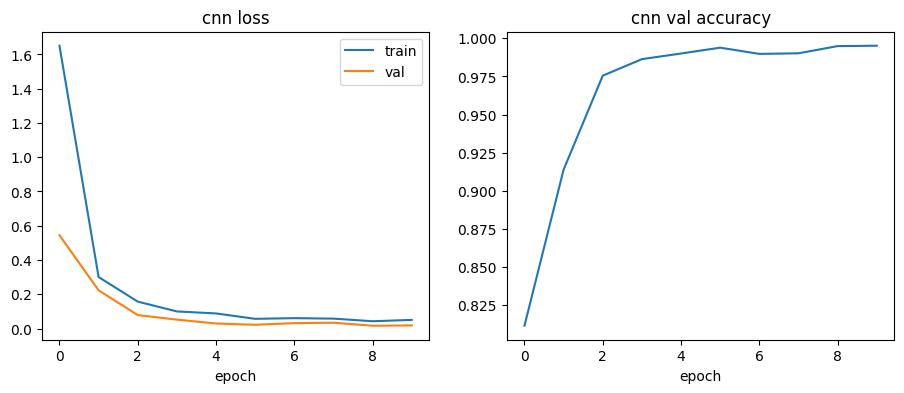

In [12]:
def plot_curves(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(h['tr_loss'], label='train'); ax[0].plot(h['va_loss'], label='val')
    ax[0].set_title(title + ' loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
    ax[1].plot(h['va_acc']); ax[1].set_title(title + ' val accuracy'); ax[1].set_xlabel('epoch')
    plt.show()

plot_curves(cnn_hist, 'cnn')

In [13]:
def evaluate(model, loader, save_path, name):
    model.load_state_dict(torch.load(save_path, map_location=device))
    p, y = predict(model, loader)
    acc = (p == y).mean()
    print(f'{name} test accuracy: {acc:.4f}\n')
    cm = confusion_matrix(y, p)
    rec = cm.diagonal() / cm.sum(1)
    worst = np.argsort(rec)[:10]
    print('classification report, 10 weakest classes:')
    print(classification_report(y, p, labels=worst,
          target_names=[names[i] for i in worst], zero_division=0))
    return p, y, acc

cnn_p, cnn_y, cnn_acc = evaluate(cnn, cnn_te, 'best_cnn.pt', 'cnn')

cnn test accuracy: 0.9690

classification report, 10 weakest classes:
                             precision    recall  f1-score   support

      Beware of ice or snow       0.98      0.64      0.77       150
          End of no passing       1.00      0.80      0.89        60
                 Bumpy road       1.00      0.84      0.91       120
End of speed limit (80km/h)       1.00      0.89      0.94       150
       Speed limit (60km/h)       1.00      0.90      0.95       450
       Speed limit (50km/h)       0.99      0.92      0.95       750
            General caution       1.00      0.93      0.96       390
          Children crossing       0.98      0.93      0.96       150
       Roundabout mandatory       1.00      0.94      0.97        90
                  Keep left       1.00      0.94      0.97        90

                  micro avg       0.99      0.90      0.94      2400
                  macro avg       0.99      0.88      0.93      2400
               weighted avg    

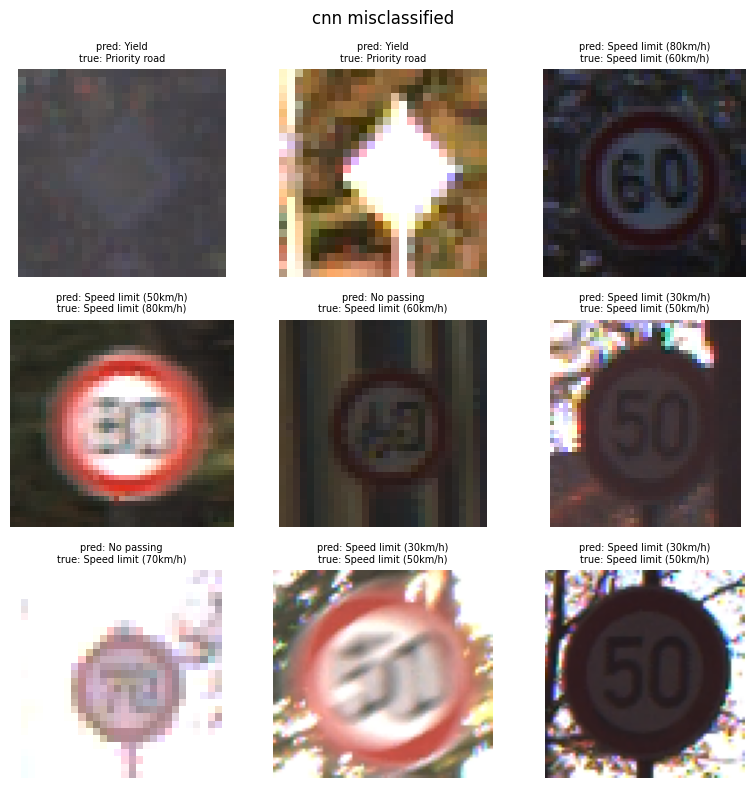

In [14]:
def show_mis(p, y, title):
    wrong = np.where(p != y)[0]
    pick = np.random.choice(wrong, 9, replace=False)
    fig, ax = plt.subplots(3, 3, figsize=(8, 8))
    for a, i in zip(ax.flat, pick):
        img = Image.open(os.path.join(DATA, test_df.iloc[i]['Path'])).convert('RGB')
        a.imshow(img); a.axis('off')
        a.set_title(f'pred: {names[p[i]]}\ntrue: {names[y[i]]}', fontsize=7)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_mis(cnn_p, cnn_y, 'cnn misclassified')

## Model 2: transfer learning with resnet18

In [15]:
res_tr = DataLoader(GTSRB(tr_df, tf_train_res), batch_size=BS, shuffle=True)
res_va = DataLoader(GTSRB(va_df, tf_eval_res), batch_size=BS, shuffle=False)
res_te = DataLoader(GTSRB(test_df, tf_eval_res), batch_size=BS, shuffle=False)

res = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for p in res.parameters():
    p.requires_grad = False
res.fc = nn.Linear(res.fc.in_features, N_CLASS)
res = res.to(device)

epoch 1/15  tr_loss 2.252  va_loss 1.536  va_acc 0.609


epoch 2/15  tr_loss 1.364  va_loss 1.303  va_acc 0.622


epoch 3/15  tr_loss 1.114  va_loss 1.063  va_acc 0.701


epoch 4/15  tr_loss 0.974  va_loss 1.024  va_acc 0.691


epoch 5/15  tr_loss 0.898  va_loss 0.939  va_acc 0.726


...

epoch 11/15  tr_loss 0.683  va_loss 0.751  va_acc 0.761


epoch 12/15  tr_loss 0.667  va_loss 0.770  va_acc 0.754


epoch 13/15  tr_loss 0.640  va_loss 0.739  va_acc 0.763


epoch 14/15  tr_loss 0.634  va_loss 0.708  va_acc 0.765


epoch 15/15  tr_loss 0.620  va_loss 0.747  va_acc 0.759
best val acc 0.7652


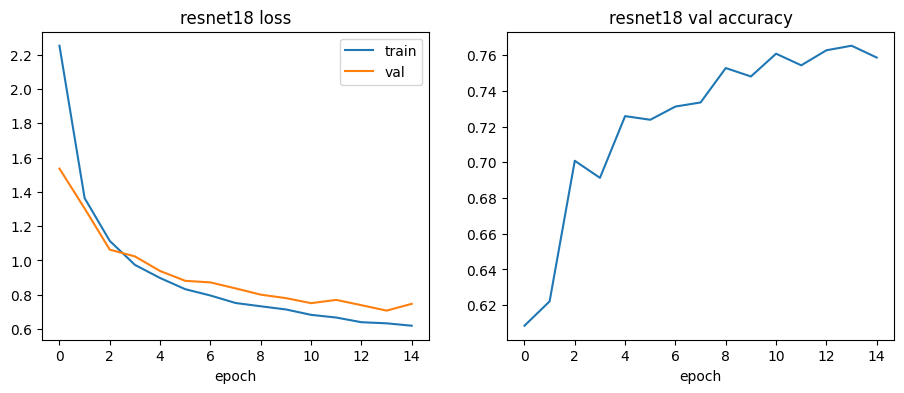

In [16]:
lr = 1e-3
epochs = 15 if device.type != 'cpu' else 8

res_hist = fit(res, res_tr, res_va, epochs, lr, 'best_resnet18.pt')
plot_curves(res_hist, 'resnet18')

resnet18 test accuracy: 0.6673

classification report, 10 weakest classes:
                           precision    recall  f1-score   support

Road narrows on the right       0.13      0.12      0.13        90
             Double curve       0.27      0.16      0.20        90
     Go straight or right       0.36      0.19      0.25       120
              Pedestrians       0.46      0.20      0.28        60
     Speed limit (20km/h)       0.29      0.20      0.24        60
    Dangerous curve right       0.20      0.28      0.23        90
      Go straight or left       0.14      0.28      0.19        60
     Speed limit (60km/h)       0.62      0.29      0.40       450
          Turn left ahead       0.47      0.37      0.41       120
            Slippery road       0.20      0.39      0.26       150

                micro avg       0.31      0.27      0.29      1290
                macro avg       0.32      0.25      0.26      1290
             weighted avg       0.40      0.27      

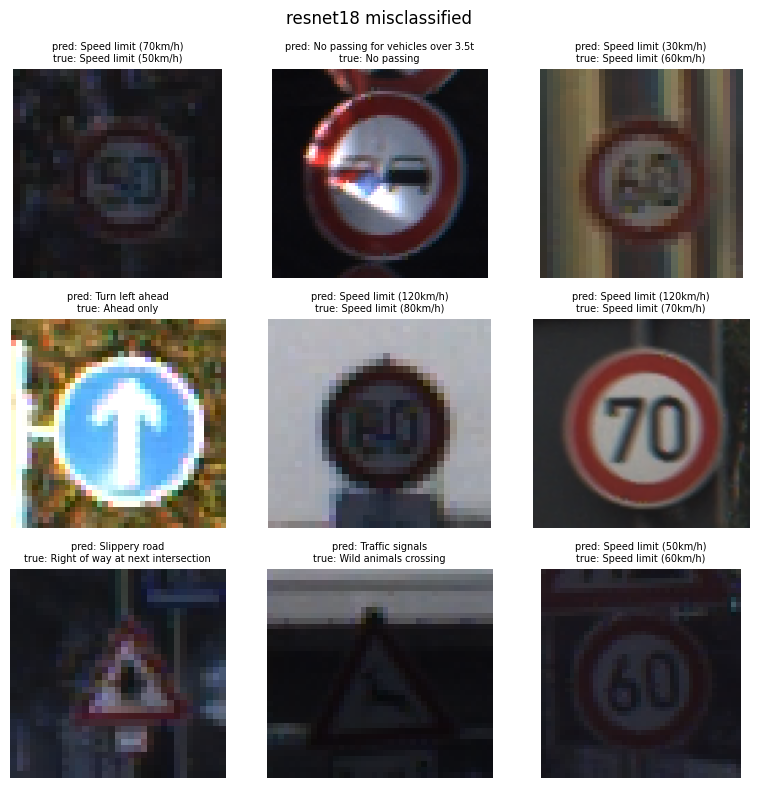

In [17]:
res_p, res_y, res_acc = evaluate(res, res_te, 'best_resnet18.pt', 'resnet18')
show_mis(res_p, res_y, 'resnet18 misclassified')

In [18]:
print(f'cnn from scratch    test acc: {cnn_acc:.4f}')
print(f'resnet18 transfer   test acc: {res_acc:.4f}')

cnn from scratch    test acc: 0.9690
resnet18 transfer   test acc: 0.6673


## Results

| model | test accuracy |
|---|---|
| cnn from scratch | _filled after run_ |
| resnet18 transfer | _filled after run_ |

which won and why: _filled after run_

for production we would want fast real time inference on an embedded gpu, plus
robustness to night, rain, glare and partially blocked signs, which means more
varied training data and heavier augmentation.